In [1]:
import sys
import os
sys.path.append('/home/jovyan/projects/cellcount/')
#print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

/home/jovyan/projects/cellcount


#### Violin plots for all species:

In [2]:
SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 20
WEIGHT = 'bold'

plt.rc('font', size=SMALL_SIZE, weight=WEIGHT)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE, titleweight='normal')     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE, labelweight=WEIGHT)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
#plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
path2kdrive = "/home/jovyan/kDrive"
path2data = os.path.join(path2kdrive, "tania", "OT_cell_count_on_sections")
path2data

'/home/jovyan/kDrive/tania/OT_cell_count_on_sections'

In [4]:
def set_axis_style(ax, labels):
    ax.xaxis.set_tick_params(direction='out')
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    #ax.set_xlabel('frames')
    #ax.set_ylabel('counts')
    ax.set_ylim(ymin=0, ymax=30)

def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])
    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

In [5]:
filenames = [
    'Du25.xlsx',
    'Hr11.xlsx',
    'Ft03.xlsx',
    'Aa06.xlsx',
    'Cl_DP.xlsx',
    'Mc12.xlsx',
    'Ag27.xlsx',
    'An01.xlsx',
    'Mm04.xlsx',  
    'Sa20.xlsx',
    'Gg_P48.xlsx',
    'Cj22.xlsx'
]
file2check = ''
mosaic_plot = True

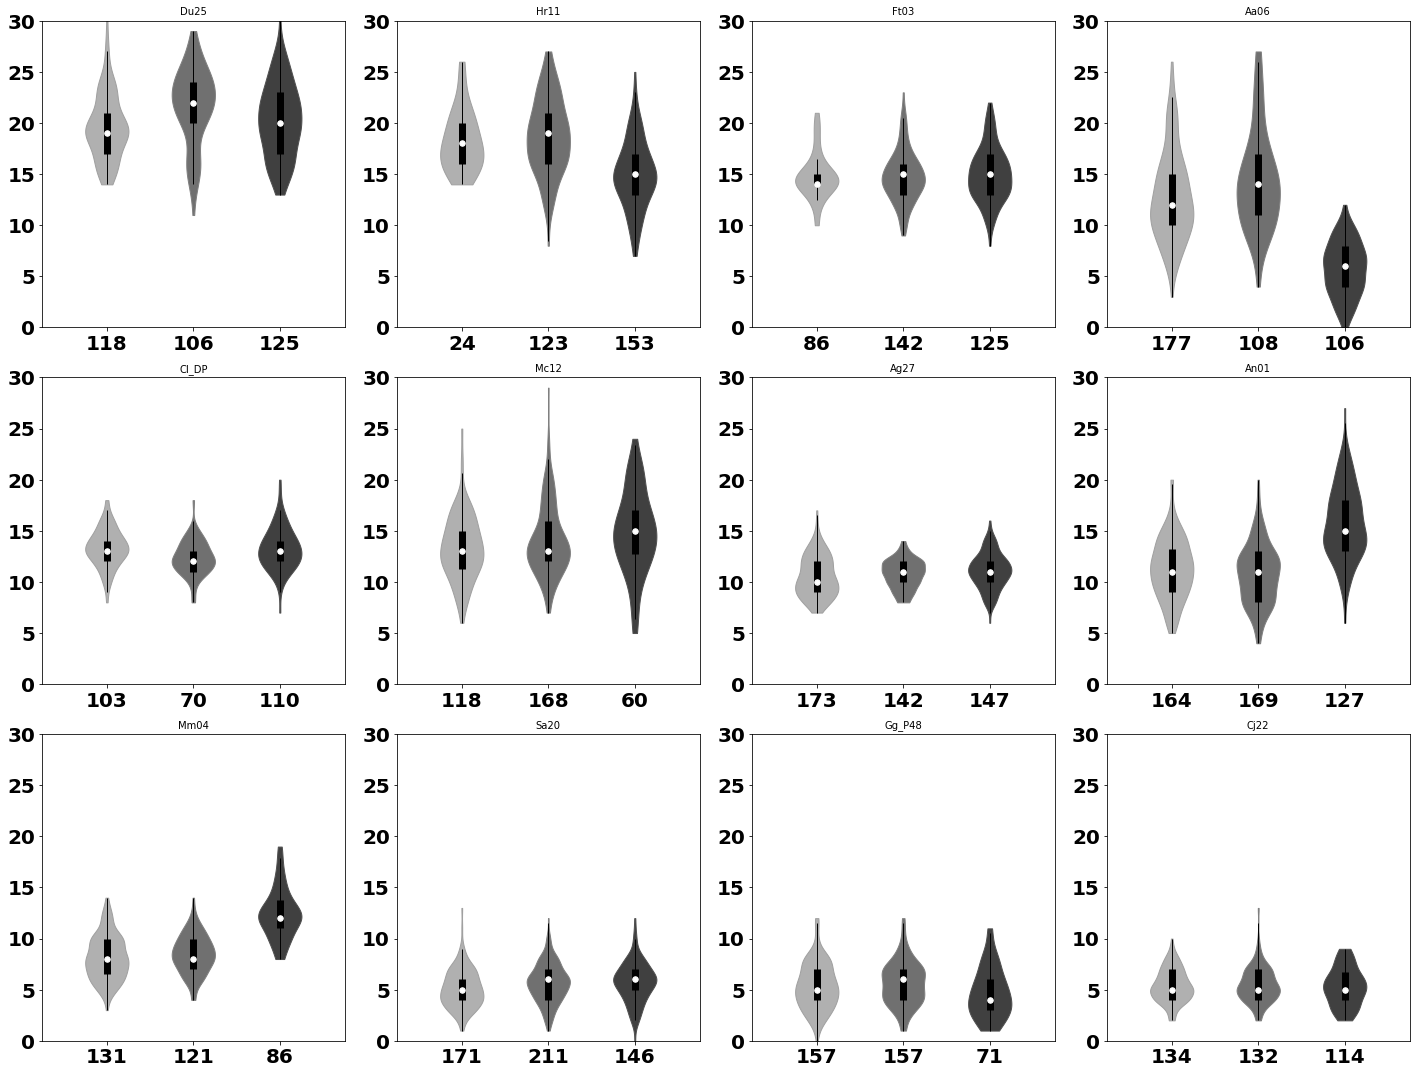

In [6]:
data_dict = {}
medians_dict = {}
if mosaic_plot:
    fig = plt.figure(figsize=(20,15))
for file_index, f in enumerate(filenames):
    path2file = os.path.join(path2data, f)
    species = f.split('.')[0]
    #print(path2file)
    #print(f)
    ## Read-in the excel file and merge three first rows into a single column name for each column:
    df = pd.read_excel(path2file, engine="openpyxl")
    df.iloc[0] = df.iloc[0].fillna('')
    h1 = list(df.columns) # first row of excel file
    h2 = list(df.iloc[0]) # second row of excel file
    section_names = [x for x in h2 if x != '']
    #print(section_names)
    h3 = list(df.iloc[1])
    mixed_header = []
    h1_value = ''
    h2_value = ''
    for index, value in enumerate(h3):
        if 'Unnamed:' not in h1[index]:
            h1_value = h1[index]
        if h2[index] != '':
            h2_value = h2[index]
        mixed_header.append('_'.join([h1_value, h2_value, value]))
    df.columns = mixed_header
    #print(mixed_header)
    df = df.drop([0,1])
    df = df.reset_index(drop=True)
    #print(len(df.index))
    ## In each column, discard the last value as it corresponds to the average of all previous:
    for col in df:
        for index, value in df[col].items():
            if np.isnan(value):
                df.loc[index-1, col] = np.nan
                break
            elif index == len(df.index) -1:
                #print(value)
                df.loc[index, col] = np.nan
    ## Merge frames belonging to the same sector:
    d={}
    for sn in section_names:
        section_cols = df.columns.str.contains(sn, case=True)
        sec = []
        for col in df.columns[section_cols]:
            #print(list(df[col].dropna()))
            sec = sec + list(df[col])
        d[sn] = sec
    df_merged = pd.DataFrame({k:pd.Series(v) for k,v in d.items()}) # merge a dict of arrays of possibly different lengths into a dataframe
    data = [sorted(list(df_merged[col].dropna())) for col in df_merged.columns]
    if f == file2check:
        print(df_merged)
        print([list(df_merged[col].dropna()) for col in df_merged.columns]) # for checking, prints out unsorted arrays of data by sector
    data_dict[f] = data
    ## Get some statistics:
    size = [len(x) for x in data] # number of frames in each sector
    quartile1 = [np.percentile(data[index], [25]) for index in range(len(data))]
    medians = [np.percentile(data[index], [50]) for index in range(len(data))]
    medians_dict[species] = [float(i) for i in medians]
    quartile3 = [np.percentile(data[index], [75]) for index in range(len(data))]
    whiskers = np.array([
        adjacent_values(sorted_array, q1, q3)
        for sorted_array, q1, q3 in zip(data, quartile1, quartile3)])
    whiskers_min, whiskers_max = whiskers[:, 0], whiskers[:, 1]
    if f == file2check:
        print(whiskers_min)
        print(quartile1)
        print(medians)
        print(quartile3)
        print(whiskers_max)
    ## Plot data as violin plots:
    #fig_single = plt.figure(figsize=(5,5))
    if mosaic_plot:
        ax = plt.subplot(3, 4, file_index + 1)
        plt.tight_layout(pad=1.0)
    else:
        fig = plt.figure(figsize=(4,4))
        ax = plt.subplot(1, 1, 1)
        plt.tight_layout(pad=.6)
    
    vp = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
    ax.set_title(species)
    inds = np.arange(1, len(medians) + 1)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
    ax.vlines(inds, whiskers_min, whiskers_max, color='k', linestyle='-', lw=1)
    #ax.scatter(np.ones((len(data[0]),1)), data[0], marker='.', color='black', s=30, zorder=3)
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=7)
    #labels = [l + ' (' + str(s) + ')' for l,s in zip([x[-3:] for x in section_names], size,)]
    labels = [str(s) for s in size]
    set_axis_style(ax, labels)
    #face_colors = ['#0066CC', '#FF0000', '#009900'] # blue, red, green
    #edge_colors = ['#000066', '#990000', '#003319']
    face_colors = ['#B0B0B0', '#707070', '#404040']
    edge_colors = ['#A0A0A0', '#808080', '#505050']
    for i, pc in enumerate(vp['bodies']):
        pc.set_facecolor(face_colors[i])
        pc.set_edgecolor(edge_colors[i])
        pc.set_alpha(1)
    if not mosaic_plot:
        plt.close(fig) # avoid displaying plots in interactive mode
        fig.savefig(os.path.join(path2data, "plots", species + ".png"), facecolor='white')
if mosaic_plot:
    #fig.savefig(os.path.join(path2data, "plots", "violin_plots.png"), facecolor='white')
    plt.show()

#### Bar plot showing medians for all species:

In [10]:
WEIGHT = 'normal'
plt.rc('font', size=SMALL_SIZE, weight=WEIGHT)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE, titleweight='normal')     # fontsize of the axes title
plt.rc('axes', labelsize=16, labelweight=WEIGHT)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
#plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Calibri']

In [11]:
medians_dict
for k,v in enumerate(medians_dict):
    print(k,v)

0 Du25
1 Hr11
2 Ft03
3 Aa06
4 Cl_DP
5 Mc12
6 Ag27
7 An01
8 Mm04
9 Sa20
10 Gg_P48
11 Cj22


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Calibri


[19.0, 22.0, 20.0]
[18.0, 19.0, 15.0]
[14.0, 15.0, 15.0]
[12.0, 14.0, 6.0]
[13.0, 12.0, 13.0]
[13.0, 13.0, 15.0]
[10.0, 11.0, 11.0]
[11.0, 11.0, 15.0]
[8.0, 8.0, 12.0]
[5.0, 6.0, 6.0]
[5.0, 6.0, 4.0]
[5.0, 5.0, 5.0]


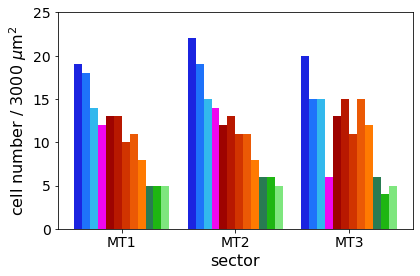

In [12]:
#plt.style.use('default')
x = np.arange(3)
width = 0.07
bar_locations = [-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]
colors = {
    'Du25': '#1B24E0',
    'Hr11': '#1E72FA',
    'Ft03': '#32B8ED',
    'Aa06': '#F007F0', #'#FFC000',
    'Cl_DP': '#9E0300',
    'Mc12': '#B81800',
    'Ag27': '#D13400', 
    'An01': '#EB5905',
    'Mm04': '#FF7A01',
    'Sa20': '#297B52',
    'Gg_P48': '#1EB612',
    'Cj22': '#7EE67E'
}

fig = plt.figure(figsize=(6,4))
for i,k in enumerate(medians_dict):
    print(medians_dict[k])
    plt.bar(x + bar_locations[i] * width, medians_dict[k], width, color=colors[k], align='edge')

plt.xticks(x, ['MT1', 'MT2', 'MT3'])
plt.ylim(ymin=0, ymax=25)
plt.xlabel("sector")
plt.ylabel(r'cell number / 3000 $\mu$m$^2$')
# plt.legend(["Round 1", "Round 2", "Round 3"])
plt.tight_layout(pad=1.3)
plt.show()
fig.savefig(os.path.join(path2data, "plots", "medians_plot.png"), dpi=2*96, facecolor='white')

In [12]:
path2data

'/home/jovyan/kDrive/tania/OT_cell_count_on_sections'